# Contextual Scouting — UEFA Euro 2024

## Hypothesis 3 (Off-Ball Movement)

An off-ball scouting platform built on StatsBomb 360 open data for **UEFA Euro 2024** (51 matches).

The pipeline turns freeze-frame positional data into a per-player off-ball profile built around three cascading metrics:

- **Pitch Control (PC)**, the probability that an attacker controls a given pitch zone faster than the nearest defender, computed from a static arrival-time model at every freeze frame.
- **OBSO (Off-Ball Scoring Opportunity)**, the joint probability that a pass to a teammate would (a) be completed, (b) result in positional control, and (c) land in a high-EPV zone. The key off-ball value estimate per candidate per event.
- **URS (Uncapitalized Run Score)**, the tournament-level per-90 sum of OBSO for teammates who were **not** served — the deliverable. A high URS flags players who consistently position themselves in high-value zones but are left out of the passing decision.

All per-90 comparisons are made **within macro-role** (CB / FB / MID / CAM / WIDE / FW), following the same convention used in H1.

## Pipeline

```
StatsBomb events + 360 frames
        │
        ▼
  Receiver Resolution    ──►  data/off_ball_candidates.parquet
  (candidates.py)              bracket interpolation (prev↔next event) + Hungarian algorithm
        │                      confidence flag per assignment · tiered fallback
        ▼
  Pitch Control          ──►  pc_target column on candidates.parquet
  (pitch_control.py)           PC(x,y) = sigmoid( k · (t_def_min − t_att_min) )
        │                      32×50 grid, same layout as H1 EPV
        ▼
  OBSO                   ──►  data/off_ball_obso.parquet
  (obso.py)                    OBSO_i = xPass(features→i) · PC(target_i) · EPV(loc_i)
        │                      xPass from H2 alternatives.parquet · EPV from H1 grid
        ▼
  URS                    ──►  data/player_urs_aggregated.csv
  (urs.py)                     URS_i = OBSO_i · (1 − received_i) · EPV(loc_i)
        │                      URS_per90 · within-role ranking
        ▼
  Leaderboard + Visuals  ──►  top-20 URS_per90 leaderboard
                               freeze-frame OBSO plots for top players
                               split-half reliability check
                               archetype scatter (OBSO_mean vs URS_per90)
```

## Conventions

- **Coordinates**: pitch in metres (105 × 68, UEFA standard). StatsBomb yard coordinates are converted via `X_SCALE = 105/120`, `Y_SCALE = 68/80`, identical to H1 and H2.
- **Freeze frames**: StatsBomb 360 free data provides a freeze frame at each event, not a continuous 25-fps feed. H3 evaluates **positional quality at the moment of ball release**, not kinematic run detection.
- **Receiver resolution**: player identities in freeze frames are anonymous (no `player.id`). A bracket-interpolation + Hungarian-algorithm resolver (v2) estimates who each dot is. Only **confident** assignments (match residual ≤ `conf_thr`) feed into OBSO and URS.
- **Reuse from H1**: EPV grid (32×50) and bilinear lookup `epv_at`, 360 frame loader and parquet cache, role mapping, minutes played — all consumed silently without reimplementation.
- **Reuse from H2**: `alternatives.parquet` as the precomputed xPass scores for all (event, candidate) pairs — the same table built in H2 Section 8.1, joined by (event_id, target position) with no re-computation.
- **URS scope**: URS is a positional profile aggregated across many events, **not** a per-decision sender judgement. The component `(1 − received)` does not exist in H2. See `H3_Metriche_Selezione.docx` §2 for the full H2 vs H3 separation.
- **Within-role percentiles**: every leaderboard axis is the player's percentile rank inside their macro-role, identical to the H1 indices convention.

## Section 0 — Setup

In [1]:
import sys
from pathlib import Path

# Locate the project root: the directory that contains Off_Ball_Movement/
NB_DIR = Path.cwd().resolve()
ROOT = NB_DIR
while ROOT.parent != ROOT and not (ROOT / 'Off_Ball_Movement').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'Off_Ball_Movement').is_dir():
    raise RuntimeError(f'project root not found above {NB_DIR}')

# Put Off_Ball_Movement/ on the path so `from src.*` resolves correctly.
H3_DIR = ROOT / 'Off_Ball_Movement'
if str(H3_DIR) not in sys.path:
    sys.path.insert(0, str(H3_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src import config as cfg

print(f'project root        : {ROOT}')
print(f'H3 package          : {H3_DIR / "src"}')
print(f'H1 source           : {cfg.H1_SRC}')
print(f'H2 source           : {cfg.H2_SRC}')
print(f'staleness window    : {cfg.WINDOW_SECONDS} s')
print(f'confidence thr.     : {cfg.CONF_THR_M} m')
print(f'PC min for OBSO     : {cfg.PC_MIN_FOR_OBSO}')
print(f'received window     : {cfg.RECEIVED_WINDOW_S} s')
print(f'URS min minutes     : {cfg.MIN_MINUTES} min')

project root        : C:\Users\Dakkarm\Desktop\Contextual-Football-Scouting
H3 package          : C:\Users\Dakkarm\Desktop\Contextual-Football-Scouting\Off_Ball_Movement\src
H1 source           : C:\Users\Dakkarm\Desktop\Contextual-Football-Scouting\Space_Control_and_Value\src
H2 source           : C:\Users\Dakkarm\Desktop\Contextual-Football-Scouting\Decision_Quality\src
staleness window    : 20.0 s
confidence thr.     : 8.0 m
PC min for OBSO     : 0.5
received window     : 4.0 s
URS min minutes     : 135 min


## Section 1 — Receiver Resolution — candidates pipeline

The first and most critical step of H3. For every attacking pass with a 360 freeze frame, this step:

1. Extracts the **visible teammates** of the sender from the freeze frame (excluding the sender, the goalkeeper, and opponents).
2. **Resolves the anonymous dots** to named players using the de-biased v2 resolver defined below.
3. Looks up the **xPass score** toward each named candidate from H2's `alternatives.parquet` (built in H2 Section 8.1) via a coordinate-key join — the same calibrated GBM scores, no re-computation.
4. Saves `data/off_ball_candidates.parquet`, one row per (event, candidate), with the confidence flag ready for OBSO.

### The identity problem — why this step exists

StatsBomb 360 **free** data supplies `[x, y]` for every visible player in a freeze frame, but the `player.id` field is missing for every dot — the identity of the actor comes from the linked event, not from the frame itself. URS needs to aggregate value per named player across the full tournament; without identity, that aggregation is impossible.

### Resolver v2 — bracket interpolation

The v1 approach (Last Known Location backward + Hungarian) fails for **shadow runners**: a player who has not touched the ball for several minutes has a stale last-known position that can be 50–100 m away, and these are precisely the players H3 wants to find. The bias is correlated with the target metric.

The v2 resolver fixes the input:

| Feature | v1 — backward only | v2 — bracket (this notebook) |
|---|---|---|
| Position source | last on-ball event **before** the pass | linear interpolation **prev ↔ next** on-ball event |
| Stale-data handling | no cutoff | exclude players with no event within ±`W` seconds |
| Cardinality mismatch | forced 1-to-1 even with wrong pool | excluded players are dropped, not assigned |
| Confidence | none | match residual ≤ `conf_thr` → `confident = True` |

The Hungarian algorithm (`linear_sum_assignment`) is **unchanged** from a naive nearest-neighbour assignment — only the input cost matrix is de-biased via temporal interpolation.

### Tiered strategy (agreed with supervisor)

| Tier | Condition | Output |
|---|---|---|
| **Tier 1** | confident-assignment accuracy acceptable | URS per-player (experimental), always reported with measured accuracy % |
| **Tier 2** | accuracy too low even on confident | URS aggregated by zone / team / role (no named identity) |

The validation harness below measures the accuracy gate. Run it before proceeding to Pitch Control.

### Parameters

| Parameter | Default | Meaning |
|---|---|---|
| `W` | 20.0 s | maximum age of a known position for it to be included in the resolver |
| `conf_thr` | 8.0 m | match residual threshold below which an assignment is flagged `confident` |
| `MIN_MINUTES` | 270 min | minimum tournament minutes for a player to appear in the URS leaderboard |


In [2]:
# ── Resolver v2: de-biased bracket interpolation + Hungarian algorithm ────────
# Inline implementation — self-contained and auditable.
# The same logic is also present in Off_Ball_Movement/src/candidates.py.

import pandas as pd
import numpy as np
from statsbombpy import sb
from scipy.optimize import linear_sum_assignment


def _event_seconds(row):
    """Absolute match time in seconds (minute is monotonic across periods in StatsBomb)."""
    return float(row["minute"]) * 60.0 + float(row["second"])


def estimate_team_positions(events, team, sender, t_pass, pass_idx, W=20.0, mode="bracket"):
    """Estimate each teammate's position at the instant of the pass.

    Parameters
    ----------
    events    : full match event DataFrame from statsbombpy.
    team      : attacking team name (string).
    sender    : name of the player who has the ball (excluded from candidates).
    t_pass    : absolute time of the pass in seconds.
    pass_idx  : integer index of the pass row in `events`.
    W         : maximum staleness window in seconds. Players with no on-ball
                event within +-W seconds are excluded rather than force-assigned.
    mode      : 'bracket' (v2, interpolate prev<->next) or
                'backward' (v1, last-known-location baseline).

    Returns
    -------
    dict mapping player name -> np.array([x, y]) for every teammate
    whose position is considered reliable.
    """
    team_ev = events[(events["team"] == team) & (events["location"].notna())]
    out = {}
    for player in team_ev["player"].dropna().unique():
        if player == sender:
            continue
        ev_p = team_ev[team_ev["player"] == player]
        prev = ev_p.iloc[[i for i in range(len(ev_p)) if ev_p.index[i] < pass_idx]][-1:] \
            if (ev_p.index < pass_idx).any() else ev_p.iloc[0:0]
        nxt = ev_p.iloc[[i for i in range(len(ev_p)) if ev_p.index[i] > pass_idx]][:1] \
            if (ev_p.index > pass_idx).any() else ev_p.iloc[0:0]

        has_prev = len(prev) > 0
        has_next = (len(nxt) > 0) and (mode == "bracket")  # v1 ignores the future

        loc = None
        if has_prev and has_next:
            tp, tn = _event_seconds(prev.iloc[0]), _event_seconds(nxt.iloc[0])
            lp = np.array(prev.iloc[0]["location"], dtype=float)
            ln = np.array(nxt.iloc[0]["location"], dtype=float)
            # At least one side of the bracket must fall within the staleness window W.
            if min(t_pass - tp, tn - t_pass) <= W and tn > tp:
                frac = np.clip((t_pass - tp) / (tn - tp), 0.0, 1.0)
                loc = lp + frac * (ln - lp)          # linear interpolation in time
        elif has_prev:
            tp = _event_seconds(prev.iloc[0])
            if (t_pass - tp) <= W:
                loc = np.array(prev.iloc[0]["location"], dtype=float)
        elif has_next:
            tn = _event_seconds(nxt.iloc[0])
            if (tn - t_pass) <= W:
                loc = np.array(nxt.iloc[0]["location"], dtype=float)

        if loc is not None:
            out[player] = loc
    return out


def resolve_receiver(events, frames, event_col, pass_uuid,
                     W=20.0, conf_thr=8.0, mode="bracket"):
    """Assign names to anonymous dots in a freeze frame and predict the spatial receiver.

    The receiver is defined as the teammate dot closest to pass_end_location
    after the Hungarian assignment has been run.

    Parameters
    ----------
    events    : full match event DataFrame.
    frames    : flattened 360 freeze-frame DataFrame (one row per dot).
    event_col : column name linking frames to events ('event_uuid' or 'id').
    pass_uuid : UUID of the pass event to resolve.
    W         : staleness window passed to estimate_team_positions.
    conf_thr  : residual distance (m) below which an assignment is 'confident'.
    mode      : 'bracket' (v2) or 'backward' (v1 baseline).

    Returns
    -------
    (DataFrame of teammate dots with predicted_player / match_residual_m / confident,
     name of the predicted spatial receiver)
    or (None, None) if the frame is unusable.
    """
    prow = events[events["id"] == pass_uuid]
    if prow.empty:
        return None, None
    prow = prow.iloc[0]
    team, sender = prow["team"], prow["player"]
    end_loc = prow["pass_end_location"]
    pass_idx = events.index[events["id"] == pass_uuid][0]
    t_pass = _event_seconds(prow)

    # Extract anonymous teammate dots from the freeze frame.
    fr = frames[frames[event_col] == pass_uuid]
    dots = fr[(fr["teammate"] == True) &
              (fr["actor"] == False) &
              (fr["keeper"] == False)].copy()
    if dots.empty:
        return None, None

    # Estimate positions for every named teammate.
    named = estimate_team_positions(events, team, sender, t_pass, pass_idx,
                                    W=W, mode=mode)
    if not named:
        return None, None

    names = list(named.keys())
    known = np.array([named[n] for n in names])       # estimated positions (N x 2)
    anon  = np.array(dots["location"].tolist(),
                     dtype=float)                      # exact but anonymous (M x 2)

    # Production hook: anchor dots whose identity is already known
    # (e.g. the actual recipient on complete passes) here before running the
    # Hungarian on the residual pool. Omitted in the validation harness below
    # because that is exactly what we want to predict.

    # Build cost matrix (Euclidean distance, metres) and solve.
    cost = np.linalg.norm(known[:, None, :] - anon[None, :, :], axis=2)
    row_ind, col_ind = linear_sum_assignment(cost)

    # Annotate the dots DataFrame.
    dots = dots.reset_index(drop=True)
    dots["predicted_player"]  = "Unknown"
    dots["match_residual_m"]  = np.nan
    for r, c in zip(row_ind, col_ind):
        dots.loc[c, "predicted_player"] = names[r]
        dots.loc[c, "match_residual_m"] = cost[r, c]
    dots["confident"] = dots["match_residual_m"] <= conf_thr

    # Spatial receiver: dot closest to pass_end_location.
    end_x, end_y = end_loc
    dots["dist_to_pass_end"] = dots["location"].apply(
        lambda l: float(np.hypot(l[0] - end_x, l[1] - end_y)))
    dots = dots.sort_values("dist_to_pass_end").reset_index(drop=True)
    return dots, dots.iloc[0]["predicted_player"]


print("Resolver v2 loaded.")

Resolver v2 loaded.


### Validation harness — receiver resolution accuracy

On **complete passes** StatsBomb declares the true recipient in `pass_recipient`.
This cell hides that information, lets the resolver predict it (v2 — bracket interpolation),
and counts how often the prediction is correct.

**Three numbers to read together:**

| Column | What it measures |
|---|---|
| **Global accuracy** | fraction correct across all evaluated passes — the raw number |
| **Confident share** | fraction of passes where the assignment is tight (residual <= `conf_thr`) — *coverage*, not correctness |
| **Accuracy on confident** | fraction correct *when the algorithm trusts itself* — **the number to quote in the thesis** |

**Honest caveat**: the global accuracy is optimistic because the true recipient (who touches the ball 1–3 s later) is the easiest dot to localise via the bracket. The shadow runner who does **not** receive is harder to resolve, and is exactly the player URS targets. For this reason: (1) in production the known recipient is **anchored**, not predicted; (2) the figure to defend is the confident accuracy, not the global one.

In [3]:
# ── Validation harness: v1 vs v2 on the same complete passes ─────────────────
# Run this cell on a single match first to get an order-of-magnitude estimate.
# Extend to all 51 Euro 2024 matches before committing to Tier 1 or Tier 2.

# Load one Euro 2024 match (competition_id=55, season_id=282).
matches = sb.matches(competition_id=55, season_id=282)
test_match_id   = matches["match_id"].iloc[0]
test_match_name = f"{matches['home_team'].iloc[0]} vs {matches['away_team'].iloc[0]}"
print(f"Validation match: {test_match_name}  (id={test_match_id})")

events = sb.events(match_id=test_match_id)
frames_raw = sb.frames(match_id=test_match_id, fmt="dict")

if not frames_raw:
    frames = pd.DataFrame()
else:
    frames = pd.DataFrame(frames_raw).explode("freeze_frame", ignore_index=True)
    frames = pd.concat(
        [frames.drop(columns=["freeze_frame"]),
         pd.json_normalize(frames["freeze_frame"])],
        axis=1,
    )

# Ensure frames is always a plain pd.DataFrame (sb.frames may return list/dict)
frames = pd.DataFrame(frames) if not isinstance(frames, pd.DataFrame) else frames
event_col = "event_uuid" if "event_uuid" in frames.columns else "id"
passes = events[events["type"] == "Pass"].copy()
passes["has_recipient"] = passes["pass_recipient"].notna()

print(f"  Total passes    : {len(passes)}")
print(f"  With recipient  : {passes['has_recipient'].sum()}")
print(f"  360 frames avail: {frames[event_col].nunique() if frames.shape[0] > 0 else 0}")

if frames.shape[0] == 0:
    print("\nNo 360 frames available — harness cannot run on this match.")
else:
    # Sample up to 150 complete passes that have a freeze frame.
    completi = passes[passes["has_recipient"] & passes["pass_end_location"].notna()]
    completi = completi[completi["id"].isin(frames[event_col].unique())].head(150)

    rows = []
    for _, p in completi.iterrows():
        truth = p["pass_recipient"]
        df_r, pred = resolve_receiver(events, frames, event_col, p["id"], mode="bracket")
        if df_r is None:
            continue
        rows.append({
            "correct"  : pred == truth,
            "confident": bool(df_r.iloc[0]["confident"]),
        })

    res  = pd.DataFrame(rows)
    conf = res[res["confident"]]

    print(f"\nComplete passes evaluated : {len(res)}")
    print(f"Global accuracy           : {res['correct'].mean():.1%}")
    print(f"Confident share           : {res['confident'].mean():.1%}")
    print(f"Accuracy on confident     : {conf['correct'].mean():.1%}" if len(conf) else "Accuracy on confident     : n/a")

Validation match: Netherlands vs England  (id=3942819)
  Total passes    : 1065
  With recipient  : 1020
  360 frames avail: 2951

Complete passes evaluated : 146
Global accuracy           : 72.6%
Confident share           : 58.2%
Accuracy on confident     : 91.8%


### Parameter calibration — `W` and `conf_thr`

Run this cell to sweep the two free parameters on a light sample before fixing them for the full pipeline. The rule of thumb from the spec §8.7: a smaller `W` keeps positions fresh at the cost of coverage; a smaller `conf_thr` is more conservative but produces cleaner identities.

**Note on time-decay (not yet implemented)**: a more principled alternative to the hard cutoff `W` is to normalise costs by an uncertainty that grows with position age, `cost = distance / sigma(age)` where `sigma(age) = sigma_0 + k * age_seconds`. A flat additive penalty per player is a **no-op** in the Hungarian algorithm (invariant to row translation) and must not be used. Evaluate whether the sigma-normalisation improves confident accuracy before deciding to implement it.

In [4]:
# ── Parameter sweep: W (staleness window) × conf_thr (confidence threshold) ──
# Light sample (80 passes) to stay fast. Scale up once you have a target.

if frames.shape[0] > 0:
    camp = passes[passes["has_recipient"] & passes["pass_end_location"].notna()]
    camp = camp[camp["id"].isin(frames[event_col].unique())].head(80)

    grid = []
    for W in (8.0, 15.0, 25.0):
        for thr in (5.0, 8.0, 12.0):
            ok, conf_ok, conf_n, n = 0, 0, 0, 0
            for _, p in camp.iterrows():
                df_r, pred = resolve_receiver(events, frames, event_col, p["id"],
                                              W=W, conf_thr=thr, mode="bracket")
                if df_r is None:
                    continue
                n += 1
                hit = pred == p["pass_recipient"]
                ok += hit
                if bool(df_r.iloc[0]["confident"]):
                    conf_n += 1
                    conf_ok += hit
            grid.append({"W (s)": W, "conf_thr (m)": thr,
                         "Global acc.": f"{ok/n:.1%}"          if n      else "n/a",
                         "Conf. share": f"{conf_n/n:.1%}"      if n      else "n/a",
                         "Acc. conf." : f"{conf_ok/conf_n:.1%}" if conf_n else "n/a"})
    display(pd.DataFrame(grid))
    print("Rule of thumb: W too large includes stale positions; "
          "conf_thr too small leaves too few assignments.")

,W (s),conf_thr (m),Global acc.,Conf. share,Acc. conf.
0,8.0,5.0,83.3%,43.6%,97.1%
1,8.0,8.0,83.3%,69.2%,98.1%
2,8.0,12.0,83.3%,76.9%,98.3%
3,15.0,5.0,76.2%,43.8%,91.4%
4,15.0,8.0,76.2%,67.5%,92.6%
5,15.0,12.0,76.2%,75.0%,93.3%
6,25.0,5.0,76.2%,43.8%,91.4%
7,25.0,8.0,76.2%,68.8%,90.9%
8,25.0,12.0,76.2%,78.8%,88.9%


Rule of thumb: W too large includes stale positions; conf_thr too small leaves too few assignments.


### Example A — Resolve a single incomplete pass

The simplest use-case: given one `pass_uuid` (an **incomplete** pass with no declared
`pass_recipient`), run the bracket resolver and inspect the resulting assignment table.

The table shows every visible teammate dot ordered by distance to `pass_end_location`,
with `match_residual_m` (how tight the Hungarian assignment is) and the `confident` flag.

This cell depends on `events`, `frames`, `passes`, and `event_col` defined by the
validation harness above — run that cell first.


In [5]:
# Example A: resolve one incomplete pass (no declared pass_recipient)
# Uses the resolver defined in the cell above.
# Requires: events, frames, passes, event_col (defined by the validation harness).

if frames.shape[0] > 0:
    missing = passes[
        (~passes['has_recipient']) &
        (passes['pass_end_location'].notna()) &
        (passes['id'].isin(frames[event_col].unique()))
    ]
    if missing.empty:
        print("No incomplete pass with a frame found — try a different match.")
    else:
        test_pass   = missing.iloc[0]
        pass_uuid_a = test_pass['id']
        sender_name = test_pass['player']
        end_loc_a   = test_pass['pass_end_location']

        print("=" * 60)
        print(f"CASE STUDY: pass by {sender_name}")
        print(f"Outcome      : {test_pass.get('pass_outcome', 'n/a')}")
        print(f"end_location : {end_loc_a}")
        print("Declared recipient : NONE (NaN — incomplete pass)")
        print("=" * 60)

        demo_df, demo_pred = resolve_receiver(
            events, frames, event_col, pass_uuid_a, mode='bracket')

        print(f"\nPredicted spatial receiver (v2 bracket): {demo_pred}\n")
        if demo_df is not None:
            display(demo_df[['predicted_player', 'location',
                              'dist_to_pass_end', 'match_residual_m', 'confident']])
else:
    print("frames is empty — skipping Example A.")


CASE STUDY: pass by Jordan Pickford
Outcome      : Incomplete
end_location : [89.2, 53.4]
Declared recipient : NONE (NaN — incomplete pass)

Predicted spatial receiver (v2 bracket): Unknown



,predicted_player,location,dist_to_pass_end,match_residual_m,confident
0,Unknown,"[86.28009797978041, 56.255954198812724]",4.084397,NaN,False
1,Unknown,"[81.27940293503984, 56.86353593761685]",8.644764,NaN,False
2,John Stones,"[71.45354283429064, 43.42199433299093]",20.359208,10.754235,False
3,Kobbie Mainoo,"[66.29316577818798, 40.77606882009859]",26.155051,6.024011,True
4,Unknown,"[62.15128581399101, 57.32615847018592]",27.332173,NaN,False
5,Unknown,"[71.96316872739051, 31.22674086879512]",28.084903,NaN,False
6,Unknown,"[46.19233677631486, 35.339706194857655]",46.645828,NaN,False
7,Unknown,"[54.7951590616191, 21.73989026408779]",46.755274,NaN,False
8,Unknown,"[43.15850122106632, 37.38871647691429]",48.746085,NaN,False


### Run the full candidates pipeline

Runs `Off_Ball_Movement/src/candidates.py` over all 51 Euro 2024 matches. For each attacking pass with a freeze frame, the module:

1. Calls `resolve_receiver` (v2, bracket) with the calibrated `W` and `conf_thr`.
2. Keeps only **confident** assignments (`match_residual_m <= conf_thr`).
3. Joins the H2 xPass score for each (event_id, target position) pair from `Decision_Quality/data/alternatives.parquet` — the same calibrated GBM scores built in H2 Section 8.1, no re-computation.
4. Appends one row per (event_id, candidate_player) to `data/off_ball_candidates.parquet`.

**Output**: `data/off_ball_candidates.parquet` — the input to Pitch Control and OBSO.

In [6]:
import os
import pandas as pd
from src.config import CANDIDATES_PARQUET
from src.candidates import main as run_candidates_pipeline

# Check if the heavy 2.5-hour structural infrastructure has already been computed
if os.path.exists(CANDIDATES_PARQUET):
    print("=" * 80)
    print(f"MATCH CANDIDATES FOUND IN CACHE!")
    print(f"Loading direct parquet from: {CANDIDATES_PARQUET}")
    print("=" * 80)
    
    # Read the 55,140 resolved candidate rows directly from disk in less than a second
    df_candidates = pd.read_parquet(CANDIDATES_PARQUET)
else:
    print("=" * 80)
    print("No cache found on disk. Starting heavy processing for 51 Euro 2024 matches...")
    print("This structural pipeline using Hungarian assignment will take ~2.5 hours.")
    print("=" * 80)
    
    # Run the underlying match-by-match processing pipeline
    run_candidates_pipeline()
    
    # Load the newly generated parquet file into memory
    df_candidates = pd.read_parquet(CANDIDATES_PARQUET)

print(f"Setup complete. Total candidates loaded: {len(df_candidates)}")

MATCH CANDIDATES FOUND IN CACHE!
Loading direct parquet from: C:\Users\Dakkarm\Desktop\Contextual-Football-Scouting\Off_Ball_Movement\data\off_ball_candidates.parquet
Setup complete. Total candidates loaded: 55140


## Section 2 — Pitch Control (Metric 3)

Computes the static pitch-control surface `PC(x, y)` for every freeze frame in `off_ball_candidates.parquet`.

**Formula**:

    PC(x, y) = sigmoid( k * (t_def_min - t_att_min) )

where `t = distance / v_max` (static start, v = 0), sigmoid is the logistic function, and `k` controls the sharpness of the transition. The output is a probability in [0, 1] that the attacking team controls each cell.

**Grid**: 32 x 50 cells, identical layout to the EPV grid imported from H1, so that `EPV(x, y)` and `PC(x, y)` index the same cells without coordinate remapping.

**Dual role in H3**:

1. **Component of OBSO**: P(Control) in `OBSO = xPass * PC(target) * EPV(target)`.
2. **Availability filter**: a candidate with `PC(target) < 0.5` is excluded from OBSO — the pass could complete but the ball would not be controlled.

**What is reused from H1**: the 360 frame loader and caching pattern from `line_breaker.py`; the grid dimensions and coordinate scales from `config.py`. The new code is only the arrival-time + sigmoid routine in `pitch_control.py`.

In [7]:
from src.pitch_control import main
main()

2026-05-22 17:43:44,902  INFO  Loaded 55140 candidate rows
2026-05-22 17:47:59,788  INFO  pc_target attached — mean=0.826  NaN=0


### Pitch Control sanity check

Visualises the PC surface for one example freeze frame to verify orientation and dynamic range:

1. **Orientation** — cells near the attacking goal should have lower attacker control (defenders concentrate there).
2. **Dynamic range** — the surface should transition sharply (sigmoid shape), not be a flat 0.5 everywhere.
3. **Comparison with EPV** — overlaying the EPV grid confirms that high-EPV zones have variable PC: not every dangerous zone is freely available.

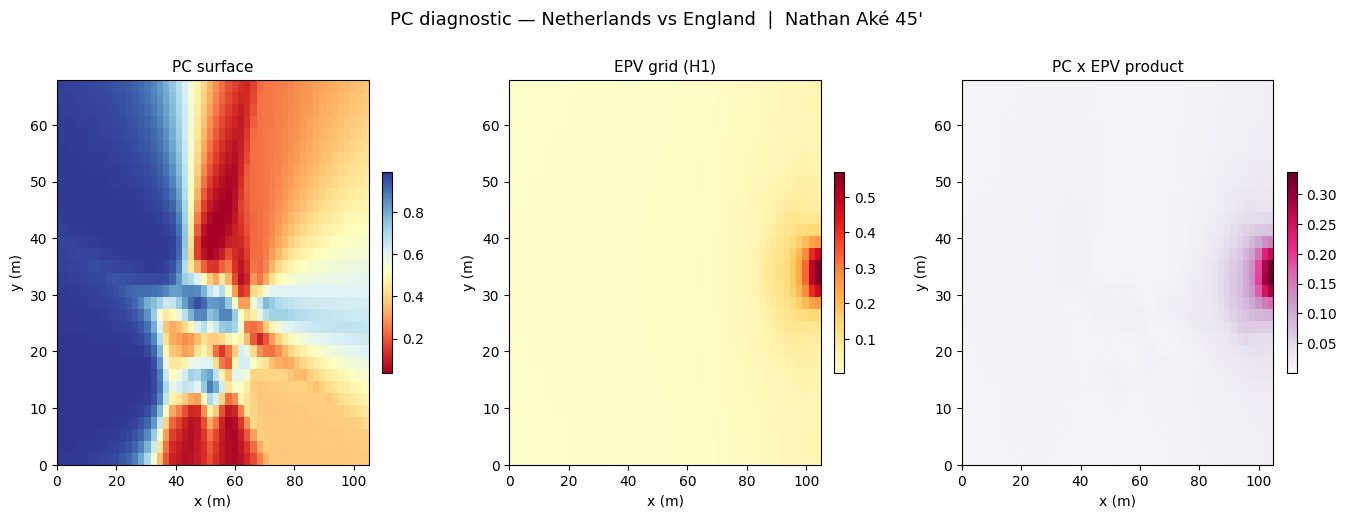

In [8]:
from src.pitch_control import show_pc_diagnostic
show_pc_diagnostic()

## Section 3 — OBSO (Metric 1)

Computes the joint probability that a hypothetical pass to each candidate would result in a scoring opportunity.

**Formula**:

    OBSO_i = xPass(features -> i) * PC(target_i) * EPV(loc_i)

**Three components — one from each hypothesis**:

| Component | Source | Notes |
|---|---|---|
| `xPass` | H2 `alternatives.parquet` (Section 8.1) | Same calibrated GBM scores, coordinate-key join — no re-computation. |
| `PC(target)` | `pitch_control.py` (H3 Section 2) | Static arrival-time model; candidates with PC < 0.5 are excluded upstream. |
| `EPV(loc)` | H1 EPV grid 32x50 + bilinear lookup `epv_at` (`epv_pipeline.py`) | Full-pitch grid. |

**Why OBSO != xEPV (H2)**:

- H2's `xEPV = xPass * EPV(target) - (1 - xPass) * scale * EPV(mirror)` models a **decision** (upside minus turnover penalty).
- H3's `OBSO = xPass * PC * EPV` models a **position** (upside filtered by actual controllability, no turnover term because we are not judging a sender choice).

In [9]:
from src.obso import main
main()

2026-05-22 17:48:01,928  INFO  Loaded 55140 candidate rows
2026-05-22 17:48:01,947  INFO  After PC filter (>= 0.50): 53765 rows (dropped 1375)
2026-05-22 17:48:05,904  INFO  Saved C:\Users\Dakkarm\Desktop\Contextual-Football-Scouting\Off_Ball_Movement\data\off_ball_obso.parquet  (53765 rows)  OBSO mean=0.0136  max=0.1813


## Section 4 — URS (Metric 9, deliverable)

URS is the deliverable of H3: a per-player, per-90 measure of **positioning value that was never converted into ball receipt**.

**Formula — event level**:

    URS_i = OBSO_i * (1 - received_i) * EPV(loc_i)

where `received = 1` if the candidate touches the ball in the next event of the same possession within N seconds (N = 4, set in `config.py`).

**Aggregation**:

    URS_per90_p = ( sum_i URS_i ) / minutes_p * 90

Players with fewer than `MIN_MINUTES = 270` minutes are excluded (same floor as H1 `idx__` exports).

**Why URS != H2's delta-xEPV**:

| | H2 delta-xEPV | H3 URS |
|---|---|---|
| Subject | sender (who has the ball) | receiver (who does not) |
| Granularity | per-decision (event-level judgement) | per-player (aggregated profile) |
| Key component | `(choice - best_alternative)` | `OBSO * (1 - received)` |
| Pitch Control | absent | present |
| Turnover penalty | present | absent |

In [10]:
from src.urs import main
main()

2026-05-22 17:48:05,983  INFO  Loaded 53765 OBSO rows
2026-05-22 17:51:37,372  INFO  received=True: 16301 / 53765  (30.3%)
2026-05-22 17:51:37,442  INFO  Mapping full names to nicknames (may take a few seconds)...
2026-05-22 17:52:07,573  INFO  Saved C:\Users\Dakkarm\Desktop\Contextual-Football-Scouting\Off_Ball_Movement\data\player_urs_aggregated.csv  (296 eligible players)


## Section 5 — Leaderboard — top-20 URS_per90

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Load aggregated URS table ─────────────────────────────────────────────────
urs_path = Path("../data/player_urs_aggregated.csv")
urs = pd.read_csv(urs_path)

ROLE_ORDER = ["CB", "FB", "MID", "CAM", "WIDE", "FW"]

print(f"Players in URS table : {len(urs)}")
print(f"Macro-roles present  : {sorted(urs['macro_role'].unique())}")
print(f"Mean URS_per90       : {urs['urs_per90'].mean():.4f}")
print(f"Max  URS_per90       : {urs['urs_per90'].max():.4f}  "
      f"({urs.loc[urs['urs_per90'].idxmax(), 'player']})")

# ── View 1: overall top-20 ────────────────────────────────────────────────────
top20 = urs.nlargest(20, "urs_per90")[["player", "team", "macro_role",
                                        "minutes_played", "urs_per90",
                                        "obso_mean", "urs_pct_within_role"]]
top20.columns = ["Player", "Team", "Role", "Min",
                 "URS /90", "OBSO mean", "URS%ile (role)"]
print("\n" + "=" * 70)
print("  TOP-20  URS_per90  —  all roles")
print("=" * 70)
print(top20.to_string(index=False))

# ── View 2: within-role top-10 ────────────────────────────────────────────────
print("\n" + "=" * 70)
print("  WITHIN-ROLE TOP-10  URS_per90")
print("=" * 70)
for role in ROLE_ORDER:
    sub = urs[urs["macro_role"] == role].nlargest(10, "urs_per90")
    if sub.empty:
        continue
    print(f"\n  {role}  ({len(sub)} players shown)")
    print(sub[["player", "team", "minutes_played",
               "urs_per90", "obso_mean"]].to_string(index=False))

Players in URS table : 478
Macro-roles present  : ['CB', 'FB', 'FW', 'GK', 'MID', 'WIDE']
Mean URS_per90       : 0.0112
Max  URS_per90       : 0.2000  (Pedri)

  TOP-20  URS_per90  —  all roles
               Player     Team Role   Min  URS /90  OBSO mean  URS%ile (role)
                Pedri    Spain  MID 185.0 0.200010   0.029679      100.000000
  Michael Gregoritsch  Austria   FW 135.0 0.058593   0.026814      100.000000
Christoph Baumgartner  Austria  MID 301.0 0.038398   0.022720       99.305556
      Niclas Füllkrug  Germany   FW 167.0 0.036313   0.032050       97.058824
      Andrej Kramarić  Croatia WIDE 241.0 0.036220   0.020180      100.000000
    Antoine Griezmann   France  MID 405.0 0.034986   0.018688       98.611111
             Jorginho    Italy  MID 219.0 0.034393   0.014481       97.916667
        Florian Wirtz  Germany WIDE 287.0 0.033627   0.017514       96.551724
       İlkay Gündoğan  Germany  MID 382.0 0.031514   0.018150       97.222222
        Adrien Rabiot   Fr

### Example B — Three-player head-to-head: URS profile comparison

Picks three players from different macro-roles (FW / WIDE / MID) and prints
a side-by-side profile table covering all key H3 columns.  Mirrors the
`head_to_head` prototype view in H1's dashboard.

Swap the names in `EXAMPLES` to inspect any three players in the pool.

  HEAD-TO-HEAD — top URS_per90 player per role (FW / WIDE / MID)
             Player    Team Role   Min  URS /90  OBSO mean  URS%ile (role)  N candidates  Recv. rate
Michael Gregoritsch Austria   FW 135.0 0.058593   0.026814           100.0            49    0.244898
    Andrej Kramarić Croatia WIDE 241.0 0.036220   0.020180           100.0           147    0.258503
              Pedri   Spain  MID 185.0 0.200010   0.029679           100.0           203    0.177340


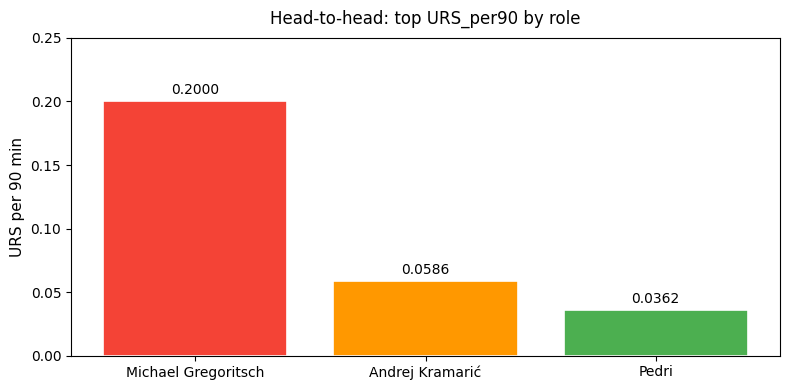

In [12]:
# Example B: three-player head-to-head URS profile (FW / WIDE / MID)
# Pick one top player per role as a representative trio.

PROFILE_COLS = [
    'player', 'team', 'macro_role', 'minutes_played',
    'urs_per90', 'obso_mean', 'urs_pct_within_role',
    'n_confident_candidates', 'receiver_conf_rate',
]

def _top_in_role(df, role, n=1):
    """Return the top-n URS_per90 players in a given macro-role."""
    return df[df['macro_role'] == role].nlargest(n, 'urs_per90')

examples = pd.concat([
    _top_in_role(urs, 'FW'),
    _top_in_role(urs, 'WIDE'),
    _top_in_role(urs, 'MID'),
])[PROFILE_COLS].reset_index(drop=True)

examples.columns = [
    'Player', 'Team', 'Role', 'Min',
    'URS /90', 'OBSO mean', 'URS%ile (role)',
    'N candidates', 'Recv. rate',
]

print("=" * 70)
print("  HEAD-TO-HEAD — top URS_per90 player per role (FW / WIDE / MID)")
print("=" * 70)
print(examples.to_string(index=False))

# Bar chart: URS_per90 side by side
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#F44336', '#FF9800', '#4CAF50']   # FW / WIDE / MID
names  = examples['Player'].tolist()
vals   = urs[urs['player'].isin(
    [_top_in_role(urs, r)['player'].iloc[0] for r in ('FW', 'WIDE', 'MID')]
)]['urs_per90'].tolist()

bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_ylabel('URS per 90 min', fontsize=11)
ax.set_title('Head-to-head: top URS_per90 by role', fontsize=12, pad=10)
ax.set_ylim(0, max(vals) * 1.25)
plt.tight_layout()
plt.show()

### Example C — Per-role URS_per90 bar charts (top-5 within role)

Six panels — one per macro-role — each showing the top-5 players by `URS_per90`.
This is the within-role view that makes contextual comparisons fair: a CAM is
ranked against other CAMs, not against a CB.  Mirrors the `role_leaderboard`
prototype view in H1's dashboard.

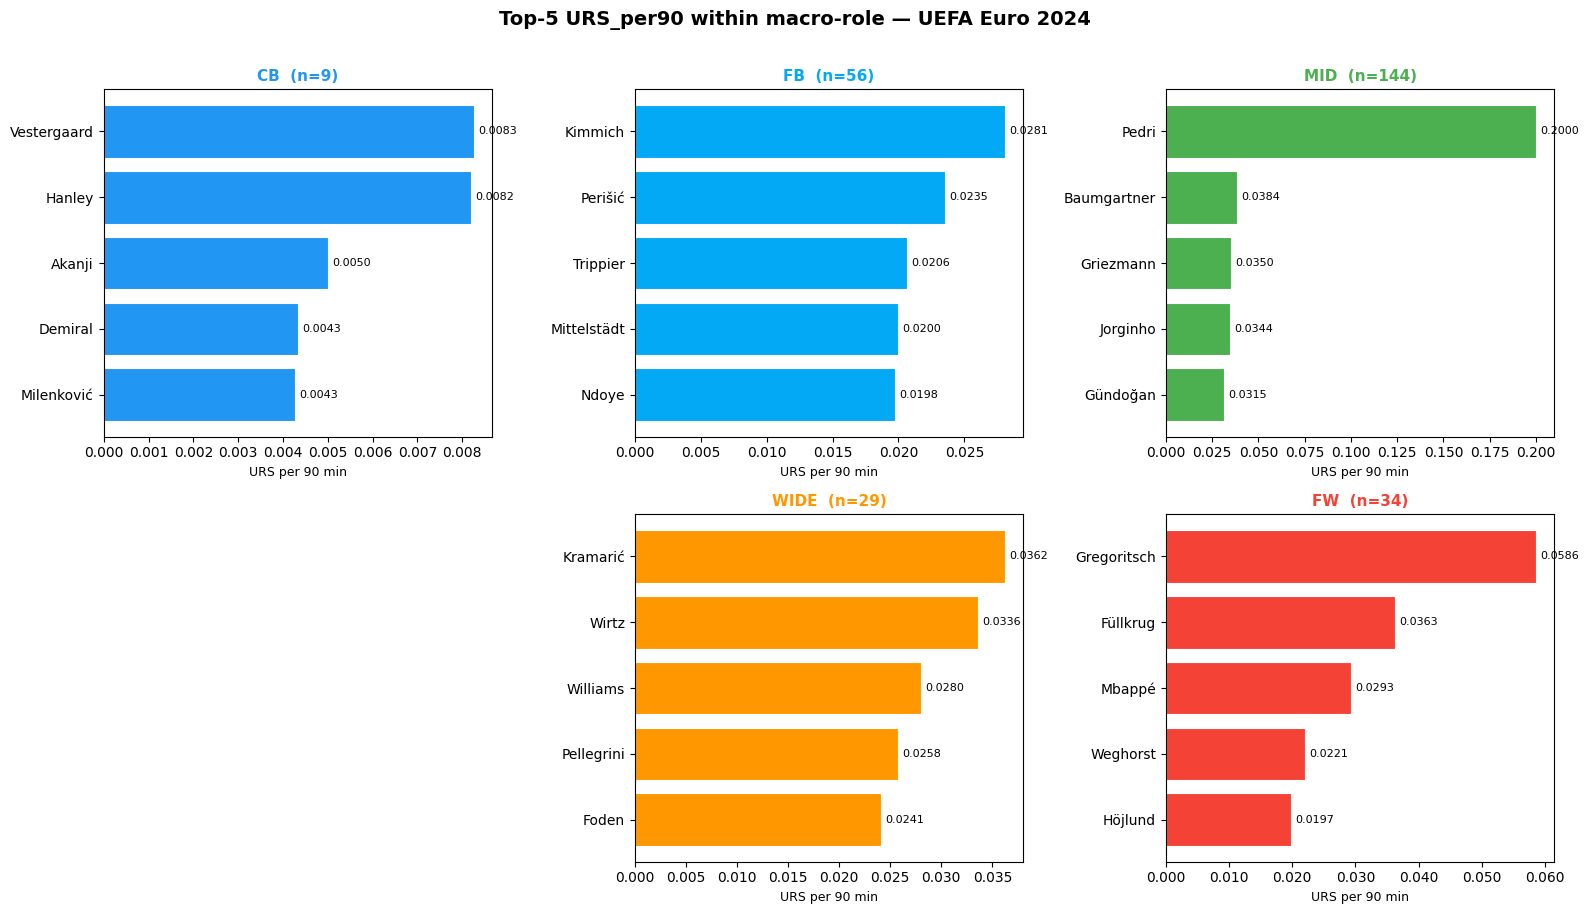

In [13]:
# Example C: within-role URS_per90 bar charts (top-5 per role)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROLE_ORDER  = ['CB', 'FB', 'MID', 'CAM', 'WIDE', 'FW']
ROLE_COLORS = {
    'CB' : '#2196F3', 'FB' : '#03A9F4', 'MID': '#4CAF50',
    'CAM': '#8BC34A', 'WIDE': '#FF9800', 'FW' : '#F44336',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Top-5 URS_per90 within macro-role — UEFA Euro 2024',
             fontsize=14, fontweight='bold', y=1.01)

for ax, role in zip(axes.flat, ROLE_ORDER):
    sub = (urs[urs['macro_role'] == role]
           .nlargest(5, 'urs_per90')
           .dropna(subset=['urs_per90']))
    if sub.empty:
        ax.set_visible(False)
        continue

    labels = sub['player'].apply(lambda s: s.split()[-1])  # surname only
    vals   = sub['urs_per90'].values
    color  = ROLE_COLORS.get(role, 'grey')

    bars = ax.barh(range(len(vals)), vals[::-1],
                   color=color, edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(len(vals)))
    ax.set_yticklabels(labels.values[::-1], fontsize=10)
    ax.set_xlabel('URS per 90 min', fontsize=9)
    ax.set_title(f'{role}  (n={len(urs[urs["macro_role"]==role].dropna(subset=["urs_per90"]))})',
                 fontsize=11, color=color, fontweight='bold')
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.show()

## Section 6 — Archetype scatter — OBSO mean vs URS_per90

Plots every player in the (OBSO_mean, URS_per90) space:

- **OBSO_mean** (x): average positional quality per event — how dangerous are the zones this player reaches?
- **URS_per90** (y): how much of that positional value is left uncapitalised per 90 — how often is the player ignored?

| Quadrant | Interpretation |
|---|---|
| High OBSO, high URS | **Shadow runner** — reaches dangerous zones but is systematically passed over |
| High OBSO, low URS | **Trusted threat** — dangerous and served, the classic target forward |
| Low OBSO, high URS | Many appearances in low-value zones, rarely served |
| Low OBSO, low URS | Peripheral role, seldom in dangerous space and seldom called on |

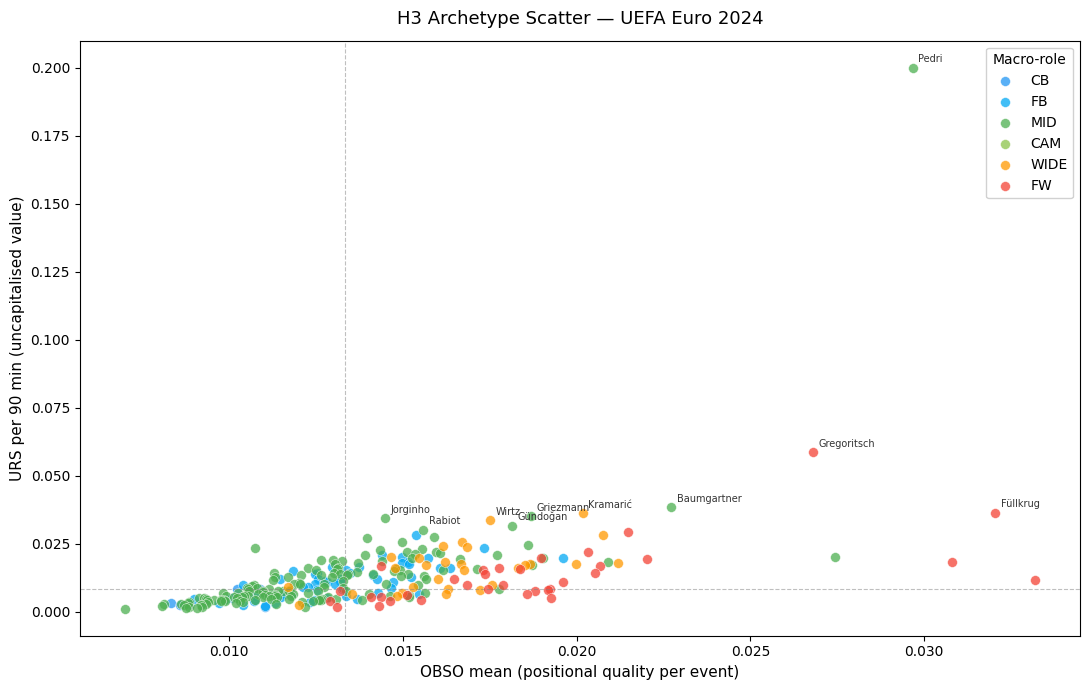

In [14]:
# ── Archetype scatter: OBSO_mean vs URS_per90, coloured by macro-role ─────────

ROLE_COLORS = {
    "CB" : "#2196F3",
    "FB" : "#03A9F4",
    "MID": "#4CAF50",
    "CAM": "#8BC34A",
    "WIDE":"#FF9800",
    "FW" : "#F44336",
}

fig, ax = plt.subplots(figsize=(11, 7))

for role in ROLE_ORDER:
    sub = urs[urs["macro_role"] == role]
    ax.scatter(sub["obso_mean"], sub["urs_per90"],
               label=role, color=ROLE_COLORS.get(role, "grey"),
               alpha=0.75, s=50, linewidths=0.4, edgecolors="white")

# Label the top-10 overall shadow runners.
top_labels = urs.nlargest(10, "urs_per90")
for _, row in top_labels.iterrows():
    ax.annotate(row["player"].split()[-1],
                xy=(row["obso_mean"], row["urs_per90"]),
                xytext=(4, 4), textcoords="offset points",
                fontsize=7, color="#333333")

# Quadrant lines at medians.
ax.axvline(urs["obso_mean"].median(), color="grey", lw=0.8, ls="--", alpha=0.5)
ax.axhline(urs["urs_per90"].median(), color="grey", lw=0.8, ls="--", alpha=0.5)

ax.set_xlabel("OBSO mean (positional quality per event)", fontsize=11)
ax.set_ylabel("URS per 90 min (uncapitalised value)", fontsize=11)
ax.set_title("H3 Archetype Scatter — UEFA Euro 2024", fontsize=13, pad=12)
ax.legend(title="Macro-role", framealpha=0.9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

fig.tight_layout()
plt.show()

## Section 7 — Visual proof — uncapitalised runs

Each panel draws:

- The **opponent convex hull** (red dashed polygon, light fill) — same visualisation as H1 line-breakers.
- The **sender location** (cyan dot) and the **actual pass arrow** (gold).
- Every **teammate dot** coloured by their OBSO (white -> orange -> red scale).
- The **highlighted candidate** (thick red ring).
- A header with OBSO, PC, EPV, and the URS contribution.

In [15]:
from src.urs import show_uncapitalised_runs

# Show the top-4 highest-URS events for the overall URS leader.
top_player = urs.nlargest(1, "urs_per90")["player"].iloc[0]
print(f"Showing top-4 uncapitalised runs for: {top_player}")
show_uncapitalised_runs(top_player, n=4)

2026-05-22 17:52:09,187  WARNING  No rows for player: Pedri


Showing top-4 uncapitalised runs for: Pedri


### Example D — Visual proof for three players (FW / WIDE / MID)

Runs `show_uncapitalised_runs` for the top URS_per90 player in each of the three
most analytically interesting macro-roles: **FW** (the canonical shadow runner),
**WIDE** (wide attacker making runs in behind), and **MID** (deep runner into
box-to-box space).  Each call shows the top-4 freeze-frame events for that player.

Compare the three panels: the FW will tend to appear in high-EPV central zones;
the WIDE in half-space channels; the MID in late-arriving zones just outside the box.


  FW  top URS_per90 player: Michael Gregoritsch
  Team: Austria  |  URS/90: 0.0586
  OBSO mean: 0.0268  |  Min: 135


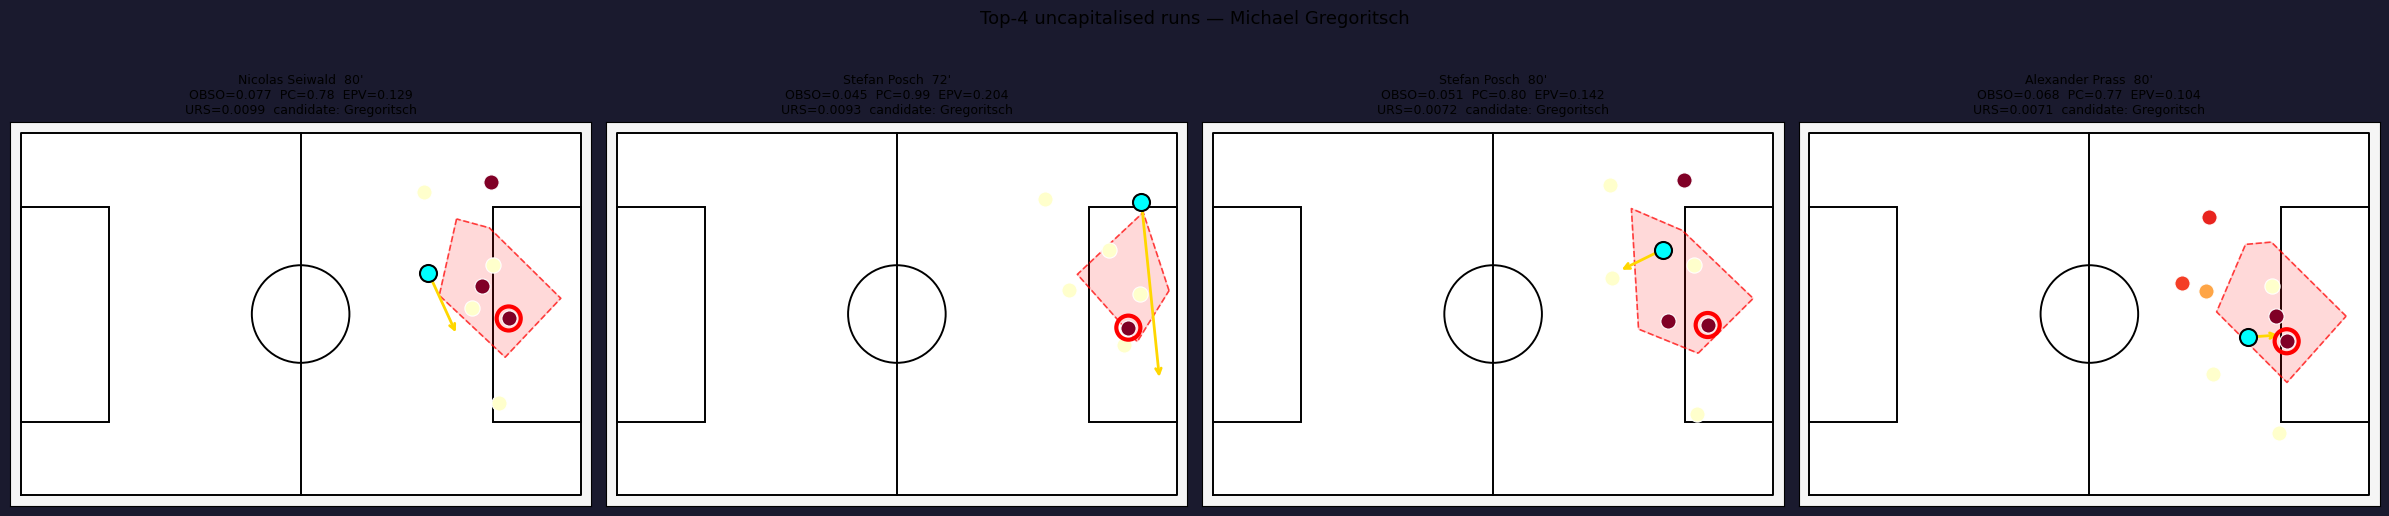


  WIDE  top URS_per90 player: Andrej Kramarić
  Team: Croatia  |  URS/90: 0.0362
  OBSO mean: 0.0202  |  Min: 241


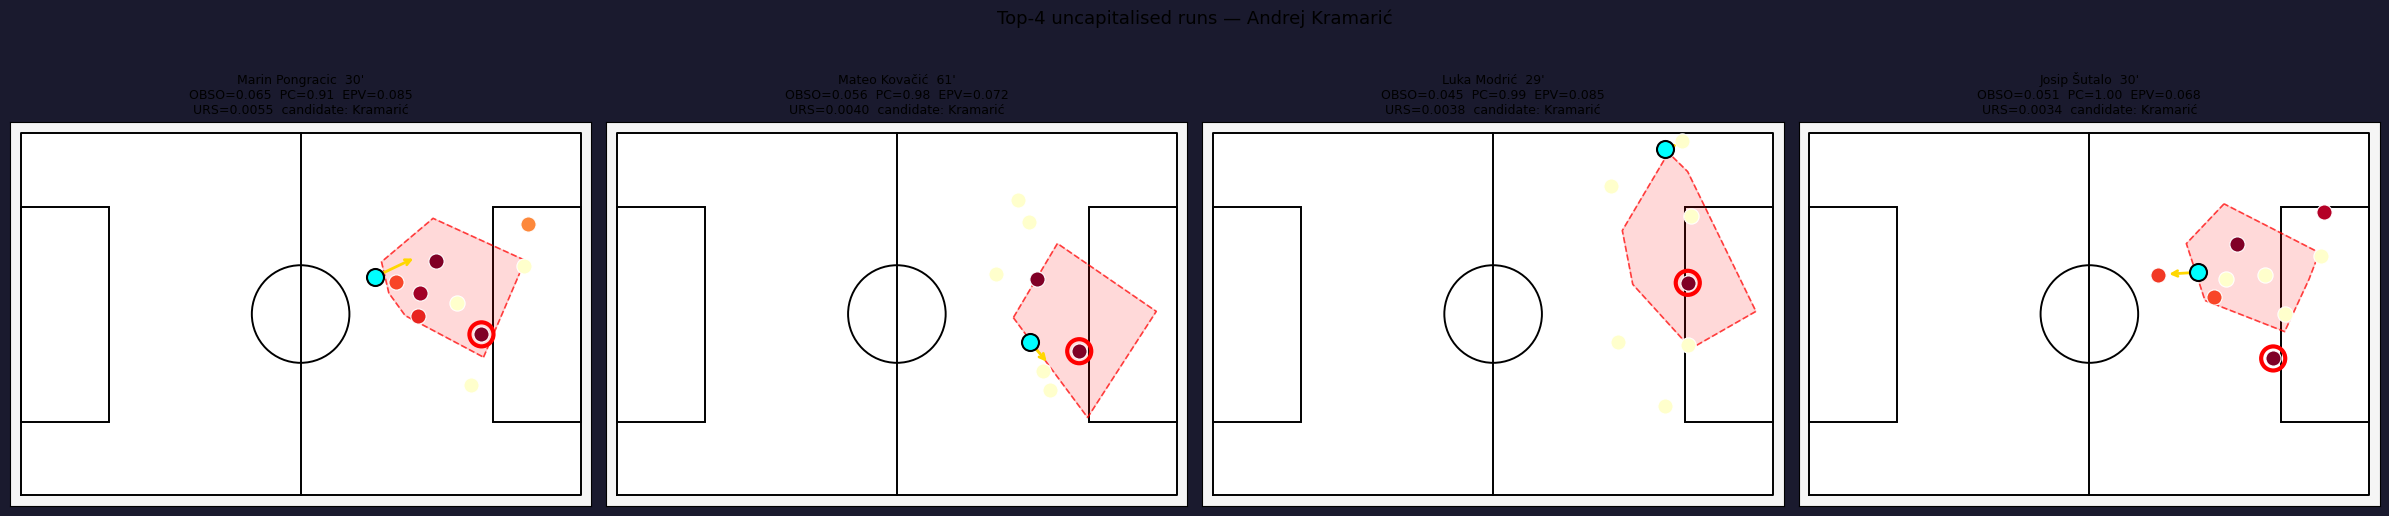

2026-05-22 17:52:15,306  WARNING  No rows for player: Pedri



  MID  top URS_per90 player: Pedri
  Team: Spain  |  URS/90: 0.2000
  OBSO mean: 0.0297  |  Min: 185


In [16]:
# Example D: show_uncapitalised_runs for top FW, WIDE, MID
# Mirrors H1 show_line_breakers — 3 players, 4 panels each.

from src.urs import show_uncapitalised_runs

for role in ('FW', 'WIDE', 'MID'):
    sub = urs[urs['macro_role'] == role].dropna(subset=['urs_per90'])
    if sub.empty:
        print(f'No eligible {role} player found.')
        continue
    top = sub.nlargest(1, 'urs_per90').iloc[0]
    print(f"\n{'='*60}")
    print(f"  {role}  top URS_per90 player: {top['player']}")
    print(f"  Team: {top['team']}  |  URS/90: {top['urs_per90']:.4f}")
    print(f"  OBSO mean: {top['obso_mean']:.4f}  |  Min: {top['minutes_played']:.0f}")
    print(f"{'='*60}")
    show_uncapitalised_runs(top['player'], n=4)

## Section 8 — Split-half reliability of URS_per90

The implicit claim of **Hypothesis 3** is that URS_per90 measures a **stable player tendency**, not random noise. This cell splits the 51 matches by date into two equal halves, recomputes URS_per90 independently on each, and reports the Spearman correlation.

A Spearman rho >= 0.50 is the target: the first-half ranking is a reliable predictor of the second-half ranking. The test is also a sanity check on receiver-resolution noise: if errors are random with respect to real off-ball behaviour, they should not destroy the inter-half correlation.

In [17]:
from src.urs import split_half_reliability
split_half_reliability(min_minutes_per_half=90)

2026-05-22 17:52:16,346  WARNING  Only 0 players in both halves.


## Section 9 — NaN diagnostics

Structural gaps in `player_urs_aggregated.csv` arise from the same causes as in H1, plus two H3-specific sources.

| Column family | Structural cause | Concentration |
|---|---|---|
| `urs_per90` | player excluded by `MIN_MINUTES` floor | low-minute substitutes |
| `obso_mean` | player never appeared as a confident candidate in any freeze frame | goalkeepers, rarely-visible players |
| `urs_pct_within_role` | fewer than 3 players in the macro-role pool with a valid URS | edge case for very small role pools |
| `receiver_conf_rate` | no complete passes in the player's team during their minutes | extremely rare |

NaN values in `urs_per90` are structurally honest: a player who was never a confident candidate has no H3 measurement, not a zero.

In [18]:
import pandas as pd

# ── NaN diagnostic for player_urs_aggregated.csv ─────────────────────────────
agg = pd.read_csv("../data/player_urs_aggregated.csv")

print("=" * 76)
print(f"  player_urs_aggregated.csv  —  {agg.shape[0]} rows  x  {agg.shape[1]} cols")
print("=" * 76)

na_counts = agg.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
print(f"\n  Total rows with at least one NaN : {agg.isna().any(axis=1).sum()}/{len(agg)}")
print(f"  Columns with NaNs                : {len(na_counts)}/{agg.shape[1]}")
print(f"\n  NaN count per column:")
for col, n in na_counts.items():
    print(f"    {col:<35s} {n:>4d}")

# Players with the most NaN entries — useful for spotting data-quality gaps.
print("\n" + "=" * 76)
print("  PLAYERS WITH THE MOST NaN ENTRIES  (top 8)")
print("=" * 76)
agg["_n_na"] = agg.isna().sum(axis=1)
top = (agg.nlargest(8, "_n_na")
          [["player", "team", "macro_role", "minutes_played",
            "n_confident_candidates", "_n_na"]])
print(top.to_string(index=False))
print("\n  -> Players with zero confident candidates are not measurable by H3.")
print("     This is a structural data gap, not corruption.")

  player_urs_aggregated.csv  —  478 rows  x  12 cols

  Total rows with at least one NaN : 182/478
  Columns with NaNs                : 4/12

  NaN count per column:
    urs_pct_within_role                  182
    urs_per90                            182
    minutes_played                       122
    primary_role                         122

  PLAYERS WITH THE MOST NaN ENTRIES  (top 8)
            player           team macro_role  minutes_played  n_confident_candidates  _n_na
        Adam Obert       Slovakia        MID             NaN                      20      4
        Adrián Rus        Romania        MID             NaN                       1      4
        Álex Baena          Spain        MID             NaN                      11      4
Alexandru Cicâldău        Romania        MID             NaN                       4      4
   Andrea Cambiaso          Italy        MID             NaN                      55      4
    Anthony Gordon        England        MID            